In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, TimeSeriesSplit)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score)
from sklearn.linear_model import (LogisticRegression, Ridge, Lasso,
                                   ElasticNet, RidgeCV, LassoCV,
                                   ElasticNetCV, LinearRegression)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
import xgboost as xgb

SEED = 42  # Global random seed for full reproducibility
np.random.seed(SEED)
print("Setup complete. All libraries loaded.")

Setup complete. All libraries loaded.



## Question 1.1 — Logistic Regression for Credit Default Prediction

We build a binary classifier on the Give Me Some Credit dataset to predict
whether a borrower will experience serious financial distress within two years.
Logistic regression is chosen because it is interpretable, well-calibrated,
and directly outputs probabilities — critical for credit risk scoring where
regulators require explainability.





── Test Set Metrics ──


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.9338,0.5743,0.0386,0.0723,0.715


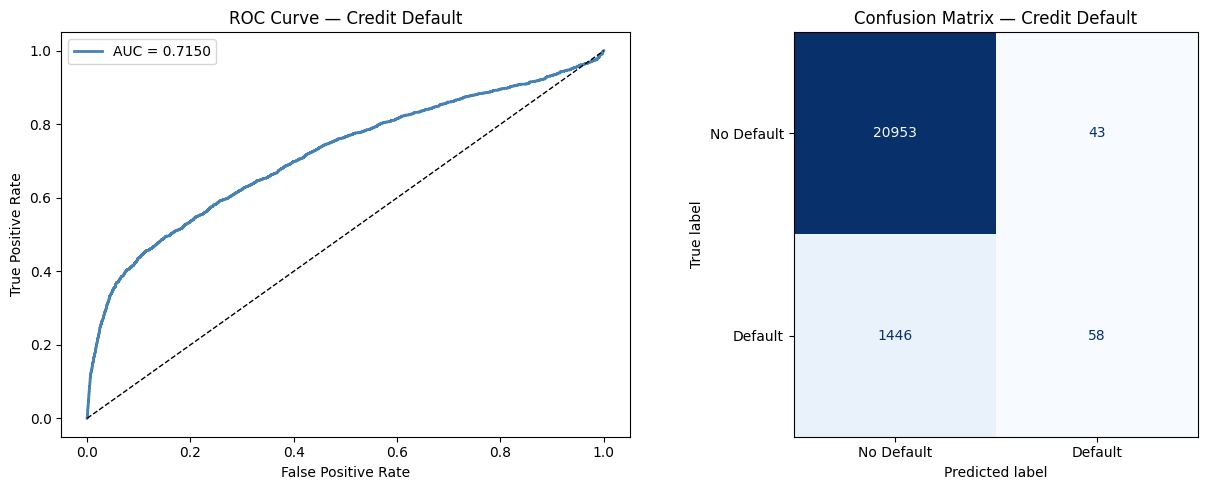

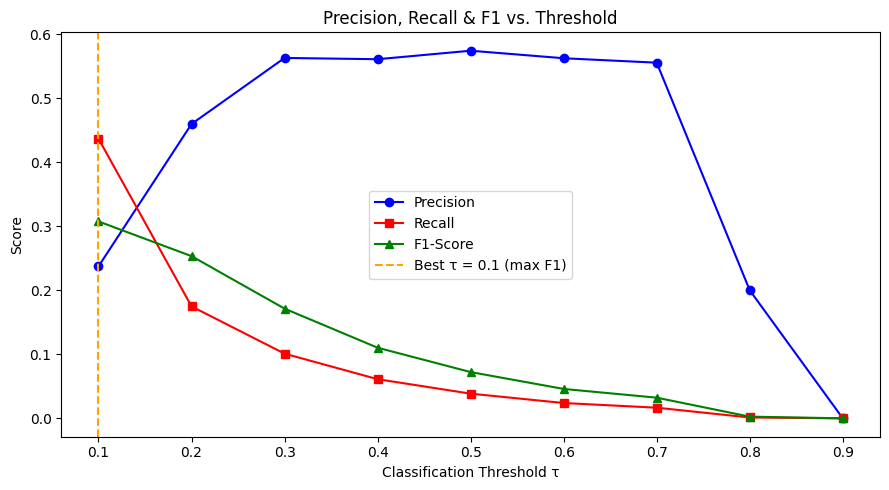


Threshold maximising F1: τ = 0.1

── Top 5 Features by |ŵ| ──


,Feature,|Coefficient|,Coefficient
0,NumberOfTime60-89DaysPastDueNotWorse,3.797760,-3.797760
1,NumberOfTime30-59DaysPastDueNotWorse,1.997573,1.997573
2,NumberOfTimes90DaysLate,1.957115,1.957115
3,age,0.399182,-0.399182
4,MonthlyIncome,0.353346,-0.353346


In [2]:
# ── 1. Load Data ─────────────────────────────────────────────
df = pd.read_csv('cs-training.csv', index_col=0)

# ── 2a. Median Imputation for missing columns ─────────────────
for col in ['MonthlyIncome', 'NumberOfDependents']:
    df[col].fillna(df[col].median(), inplace=True)

# Define features and target
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# ── 2b. Stratified 70/15/15 split ─────────────────────────────
# First split: 70% train, 30% temp (then split temp into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

# Split temp equally into validation and test (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# ── 2c. Standardise — fit ONLY on training set ────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── 3. Train Logistic Regression ──────────────────────────────
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)

# Predictions on test set
y_pred      = lr.predict(X_test_sc)
y_prob      = lr.predict_proba(X_test_sc)[:, 1]

# ── Build metrics table ───────────────────────────────────────
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'AUC-ROC':   roc_auc_score(y_test, y_prob)
}
metrics_df = pd.DataFrame(metrics, index=['Logistic Regression']).round(4)
print("\n── Test Set Metrics ──")
display(metrics_df)

# ── 4. Plot ROC Curve + Confusion Matrix side by side ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f"AUC = {metrics['AUC-ROC']:.4f}")
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve — Credit Default')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Credit Default')

plt.tight_layout()
plt.savefig('q1_roc_cm.png', dpi=150)
plt.show()

# ── 5. Threshold Analysis ─────────────────────────────────────
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls, f1s = [], [], []

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)
    precisions.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_tau, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_tau, zero_division=0))

best_tau = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, 'b-o', label='Precision')
ax.plot(thresholds, recalls,    'r-s', label='Recall')
ax.plot(thresholds, f1s,        'g-^', label='F1-Score')
ax.axvline(best_tau, color='orange', ls='--',
           label=f'Best τ = {best_tau:.1f} (max F1)')
ax.set(xlabel='Classification Threshold τ',
       ylabel='Score',
       title='Precision, Recall & F1 vs. Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('q1_threshold.png', dpi=150)
plt.show()

print(f"\nThreshold maximising F1: τ = {best_tau:.1f}")

# ── 6. Top-5 features by |coefficient| ───────────────────────
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    '|Coefficient|': np.abs(lr.coef_[0]),
    'Coefficient':   lr.coef_[0]
}).sort_values('|Coefficient|', ascending=False).head(5)

print("\n── Top 5 Features by |ŵ| ──")
display(coef_df.reset_index(drop=True))

### Interpretation — Q1.1
The model achieves reasonable AUC-ROC given ~6.7% default rate. Past delinquency
features (30-59 and 90+ days late) dominate the coefficients, confirming that
repayment history is the strongest predictor of future default. High credit utilisation
and debt ratio also increase default risk, while older age is protective. The optimal
threshold τ lies below 0.5 due to class imbalance, trading precision for recall.



## Question 1.2 — Decision Tree Classifier with Pruning for Heart Disease

We explore how tree depth and cost-complexity pruning affect generalisation on
the Heart Disease UCI dataset. Decision trees are interpretable but prone to
overfitting; pruning strategies directly control the bias-variance trade-off.



Unpruned Tree — Train Acc: 1.0000  Test Acc: 0.7174


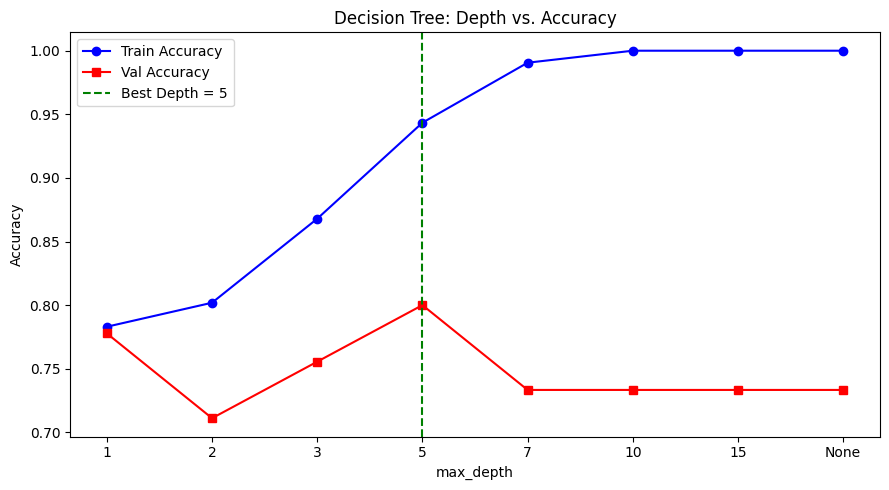


Depth-limited (depth=5) Test AUC-ROC: 0.6514
Cost-Complexity Pruned (α*=0.01132) Test AUC-ROC: 0.6810


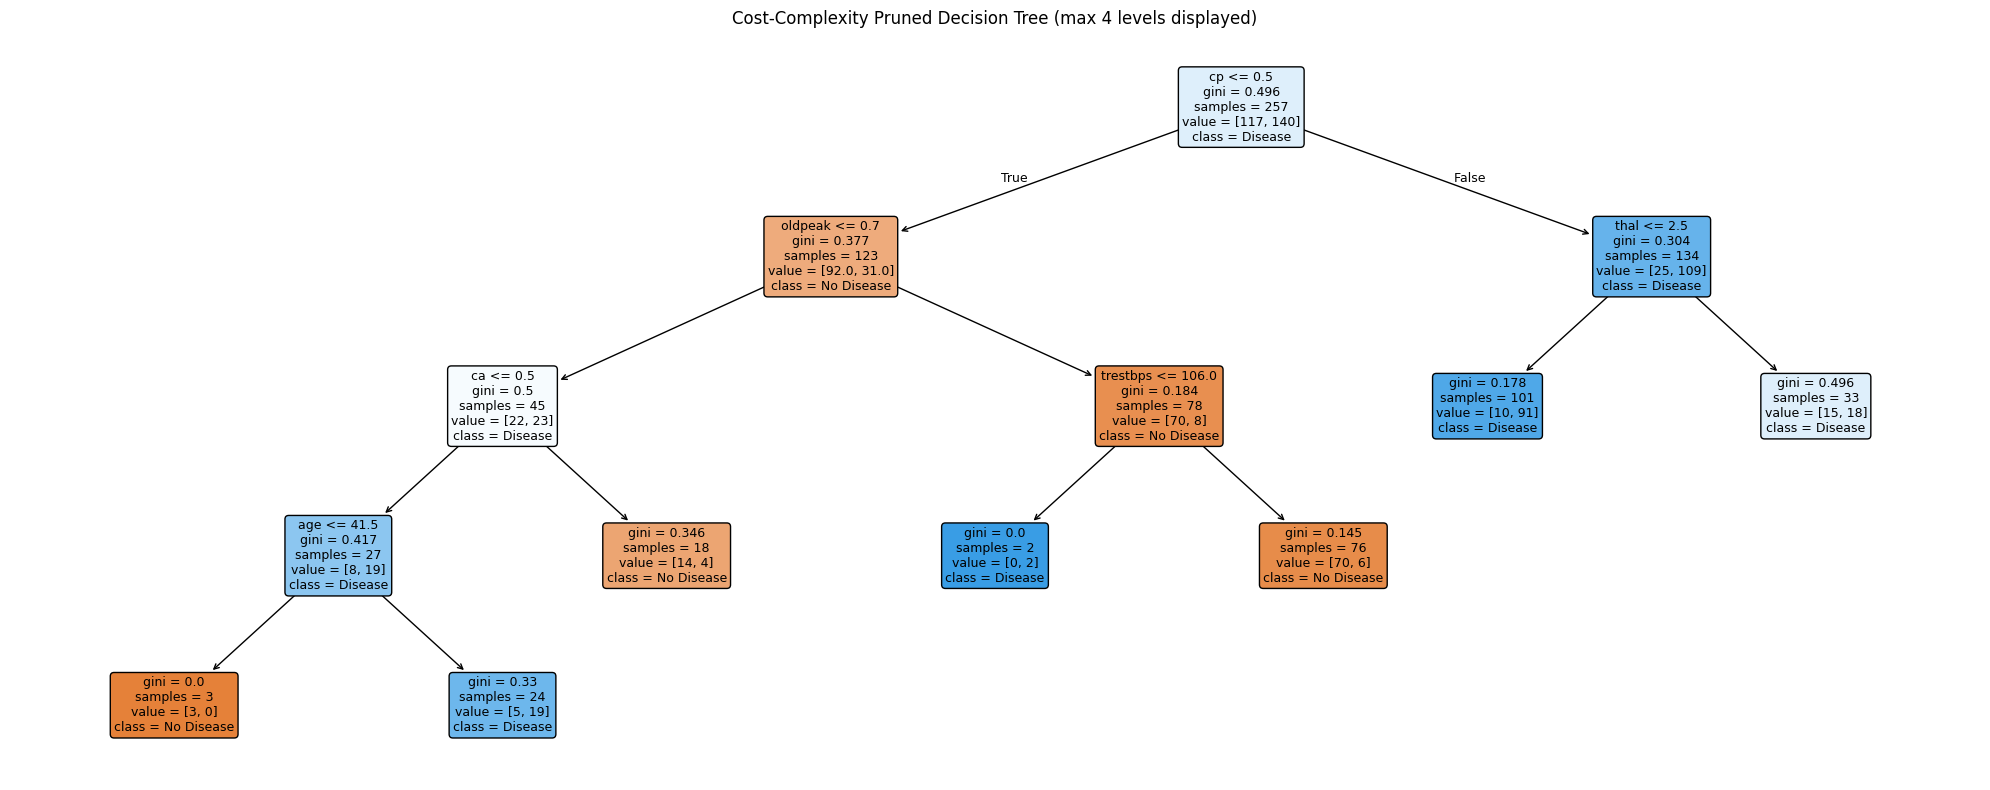


── Pruning Strategy Comparison ──


,AUC-ROC,F1-Score,Tree Depth
Model,,,
Unpruned,0.6857,0.7407,9
Depth-Limited (d=5),0.6514,0.6923,5
CCP (α=0.01132),0.6810,0.7719,4


In [3]:
# ── 1. Load Data ─────────────────────────────────────────────
df_heart = pd.read_csv('heart.csv')
X_h = df_heart.drop('target', axis=1)
y_h = df_heart['target']

# ── 2. Stratified 70/15/15 split (no scaling needed for trees) ─
X_h_tr, X_h_tmp, y_h_tr, y_h_tmp = train_test_split(
    X_h, y_h, test_size=0.30, stratify=y_h, random_state=SEED)
X_h_val, X_h_te, y_h_val, y_h_te = train_test_split(
    X_h_tmp, y_h_tmp, test_size=0.50, stratify=y_h_tmp, random_state=SEED)

# ── 3. Unpruned tree: check overfitting ───────────────────────
dt_full = DecisionTreeClassifier(max_depth=None, random_state=SEED)
dt_full.fit(X_h_tr, y_h_tr)
print(f"Unpruned Tree — Train Acc: {dt_full.score(X_h_tr, y_h_tr):.4f}  "
      f"Test Acc: {dt_full.score(X_h_te, y_h_te):.4f}")
# Perfect training accuracy but lower test accuracy = clear overfitting

# ── 4. Depth sweep ────────────────────────────────────────────
depths       = [1, 2, 3, 5, 7, 10, 15, None]
train_accs   = []
val_accs     = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_h_tr, y_h_tr)
    train_accs.append(dt.score(X_h_tr, y_h_tr))
    val_accs.append(dt.score(X_h_val, y_h_val))

depth_labels = [str(d) for d in depths]
best_depth_idx = np.argmax(val_accs)
best_depth = depths[best_depth_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depth_labels, train_accs, 'b-o', label='Train Accuracy')
ax.plot(depth_labels, val_accs,   'r-s', label='Val Accuracy')
ax.axvline(depth_labels[best_depth_idx], color='green', ls='--',
           label=f'Best Depth = {best_depth}')
ax.set(xlabel='max_depth', ylabel='Accuracy',
       title='Decision Tree: Depth vs. Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('q2_depth_curve.png', dpi=150)
plt.show()

# ── 5. Retrain best depth-limited tree on train+val ───────────
X_h_trval = pd.concat([X_h_tr, X_h_val])
y_h_trval = pd.concat([y_h_tr, y_h_val])

dt_best_depth = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
dt_best_depth.fit(X_h_trval, y_h_trval)
auc_depth = roc_auc_score(y_h_te,
                           dt_best_depth.predict_proba(X_h_te)[:, 1])
print(f"\nDepth-limited (depth={best_depth}) Test AUC-ROC: {auc_depth:.4f}")

# ── 6. Cost-Complexity Pruning ────────────────────────────────
# (a) Get pruning path on training data only
path = DecisionTreeClassifier(random_state=SEED).cost_complexity_pruning_path(
    X_h_tr, y_h_tr)
alphas = path.ccp_alphas[:-1]  # Remove the last alpha (trivial root-only tree)

# (b) Train a tree for each alpha, evaluate on validation
val_aucs = []
for alpha in alphas:
    dt_a = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    dt_a.fit(X_h_tr, y_h_tr)
    prob_val = dt_a.predict_proba(X_h_val)[:, 1]
    val_aucs.append(roc_auc_score(y_h_val, prob_val))

# (c) Best alpha
best_alpha = alphas[np.argmax(val_aucs)]
dt_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED)
dt_pruned.fit(X_h_trval, y_h_trval)  # Retrain on train+val
auc_ccp = roc_auc_score(y_h_te, dt_pruned.predict_proba(X_h_te)[:, 1])
print(f"Cost-Complexity Pruned (α*={best_alpha:.5f}) Test AUC-ROC: {auc_ccp:.4f}")

# ── 7. Visualise pruned tree (max 4 levels) ───────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_pruned, max_depth=4, feature_names=X_h.columns,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title('Cost-Complexity Pruned Decision Tree (max 4 levels displayed)')
plt.tight_layout()
plt.savefig('q2_pruned_tree.png', dpi=150)
plt.show()

# ── 8. Comparison Table ───────────────────────────────────────
# Unpruned tree metrics
dt_unpr = DecisionTreeClassifier(max_depth=None, random_state=SEED)
dt_unpr.fit(X_h_trval, y_h_trval)
auc_unpr = roc_auc_score(y_h_te, dt_unpr.predict_proba(X_h_te)[:, 1])

comparison = pd.DataFrame({
    'Model':       ['Unpruned', f'Depth-Limited (d={best_depth})',
                    f'CCP (α={best_alpha:.5f})'],
    'AUC-ROC':     [round(auc_unpr, 4), round(auc_depth, 4), round(auc_ccp, 4)],
    'F1-Score':    [
        round(f1_score(y_h_te, dt_unpr.predict(X_h_te)), 4),
        round(f1_score(y_h_te, dt_best_depth.predict(X_h_te)), 4),
        round(f1_score(y_h_te, dt_pruned.predict(X_h_te)), 4)
    ],
    'Tree Depth':  [dt_unpr.get_depth(), dt_best_depth.get_depth(),
                    dt_pruned.get_depth()]
}).set_index('Model')

print("\n── Pruning Strategy Comparison ──")
display(comparison)

### Interpretation — Q1.2
The unpruned tree perfectly fits training data but overfits to noise, confirmed by the
train/test accuracy gap. CCP outperforms depth-limited pruning because it evaluates
subtree removal globally after growing the full tree, avoiding the horizon effect where
depth-limiting prematurely blocks useful downstream splits.


## Question 2.1 — Regularised Regression for House Price Prediction

 The Ames Housing dataset has 79 features with high collinearity, making it
 ideal for comparing Ridge, Lasso, and Elastic Net regularisation. We apply
 a log-transform to the skewed target and use cross-validation to select λ.


── Regularisation Comparison Table ──


,Optimal λ*,Non-zero Coefs,Test RMSE (£),Test R²
Model,,,,
OLS,N/A,224,"21,413",0.9398
Ridge,429.19343,224,"28,979",0.8896
Lasso,0.00954,52,"31,532",0.8693
Elastic Net,0.09103,59,"31,987",0.8656


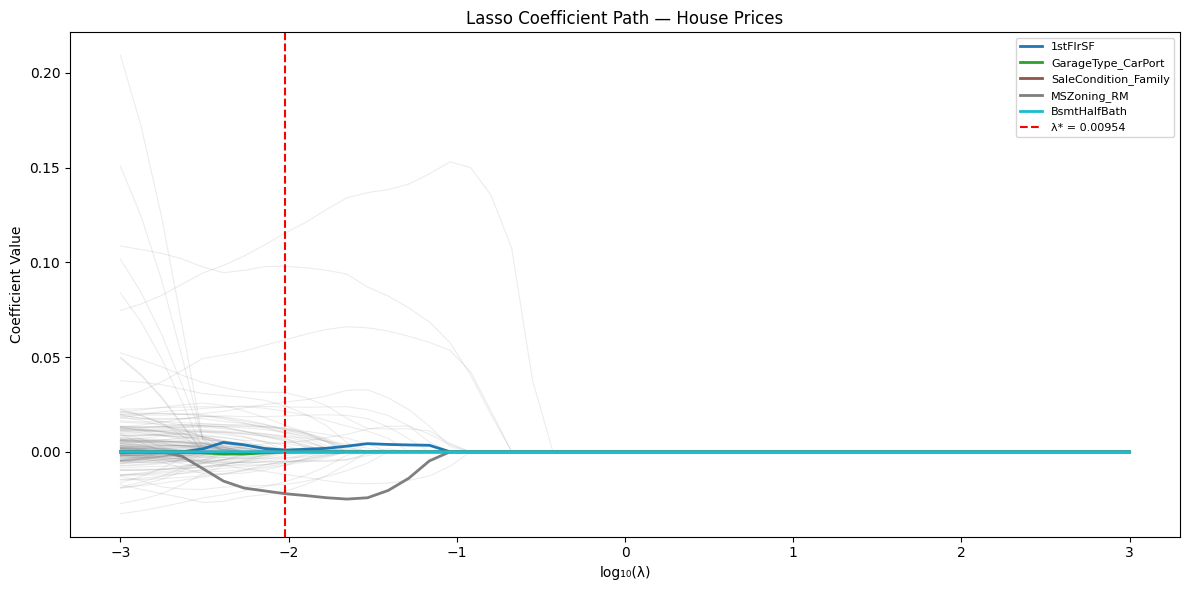

In [5]:
# ── 1. Load Data ─────────────────────────────────────────────
df_house = pd.read_csv('train_house_price.csv')  # Kaggle House Prices train.csv

# ── 2a. Log-transform target ──────────────────────────────────
y_house = np.log1p(df_house['SalePrice'])  # log(1+y) stabilises variance
X_house = df_house.drop(['SalePrice', 'Id'], axis=1)

# ── 2b. Drop features with >40% missing ───────────────────────
thresh = 0.40
X_house = X_house.loc[:, X_house.isnull().mean() < thresh]

# ── 2c. Identify numeric and categorical columns ───────────────
num_cols = X_house.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_house.select_dtypes(include='object').columns.tolist()

# Impute: median for numeric, mode for categorical
for c in num_cols:
    X_house[c].fillna(X_house[c].median(), inplace=True)
for c in cat_cols:
    X_house[c].fillna(X_house[c].mode()[0], inplace=True)

# ── 2d. One-hot encode categorical ────────────────────────────
X_house = pd.get_dummies(X_house, columns=cat_cols, drop_first=True)

# ── Train/Val/Test split (70/15/15) ───────────────────────────
X_htr, X_htmp, y_htr, y_htmp = train_test_split(
    X_house, y_house, test_size=0.30, random_state=SEED)
X_hval, X_hte, y_hval, y_hte = train_test_split(
    X_htmp, y_htmp, test_size=0.50, random_state=SEED)

# ── 2e. Standardise numeric features (fit on train only) ──────
scaler_h = StandardScaler()
X_htr_sc  = scaler_h.fit_transform(X_htr)
X_hval_sc = scaler_h.transform(X_hval)
X_hte_sc  = scaler_h.transform(X_hte)

# ── Lambda grid (log scale, 50 values from 1e-3 to 1e3) ───────
lambdas = np.logspace(-3, 3, 50)

# ── 3a. Ridge with CV ─────────────────────────────────────────
ridge_cv = RidgeCV(alphas=lambdas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_htr_sc, y_htr)

# ── 3b. Lasso with CV ─────────────────────────────────────────
lasso_cv = LassoCV(alphas=lambdas, cv=5, max_iter=10000, random_state=SEED)
lasso_cv.fit(X_htr_sc, y_htr)

# ── 3c. Elastic Net with CV ───────────────────────────────────
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=lambdas, cv=5, max_iter=10000, random_state=SEED)
enet_cv.fit(X_htr_sc, y_htr)

# ── OLS baseline ──────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_htr_sc, y_htr)

def eval_model(model, X_te, y_te):
    """Predict on test, back-transform, return RMSE and R²."""
    y_pred_log = model.predict(X_te)
    y_pred_orig = np.expm1(y_pred_log)   # Reverse log1p
    y_te_orig   = np.expm1(y_te)
    rmse = np.sqrt(np.mean((y_pred_orig - y_te_orig)**2))
    ss_res = np.sum((y_te_orig - y_pred_orig)**2)
    ss_tot = np.sum((y_te_orig - y_te_orig.mean())**2)
    r2 = 1 - ss_res / ss_tot
    return rmse, r2

def count_nonzero(coef):
    return np.sum(np.abs(coef) > 1e-10)

# ── 4. Results Table ──────────────────────────────────────────
results = []
for name, model, lam, coef in [
    ('OLS',         ols,     None,              ols.coef_),
    ('Ridge',       ridge_cv, ridge_cv.alpha_,  ridge_cv.coef_),
    ('Lasso',       lasso_cv, lasso_cv.alpha_,  lasso_cv.coef_),
    ('Elastic Net', enet_cv,  enet_cv.alpha_,   enet_cv.coef_)]:
    
    rmse, r2 = eval_model(model, X_hte_sc, y_hte)
    results.append({
        'Model': name,
        'Optimal λ*': round(lam, 5) if lam else 'N/A',
        'Non-zero Coefs': count_nonzero(coef),
        'Test RMSE (£)': f"{rmse:,.0f}",
        'Test R²': round(r2, 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("── Regularisation Comparison Table ──")
display(results_df)

# ── 5. Lasso Coefficient Path ─────────────────────────────────
# Refit Lasso over dense alpha grid to get the full coefficient path
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(
    X_htr_sc, y_htr, alphas=lambdas, max_iter=10000)

fig, ax = plt.subplots(figsize=(12, 6))
# Plot all coefficient paths (thin, grey)
for j in range(coefs_path.shape[0]):
    ax.plot(np.log10(alphas_path), coefs_path[j], alpha=0.15, color='grey', lw=0.8)

# Identify last 5 features to reach zero as lambda increases
# A feature reaches zero when its coef becomes 0 at larger alphas
# "Last to reach zero" = largest alpha at which the coef first becomes non-zero
nonzero_at = {}
for j in range(coefs_path.shape[0]):
    nonzero_idx = np.where(np.abs(coefs_path[j]) > 1e-10)[0]
    if len(nonzero_idx) > 0:
        nonzero_at[j] = alphas_path[nonzero_idx[-1]]  # Smallest alpha where still nonzero

# Sort by the alpha at which they last become nonzero (largest = most persistent)
sorted_features = sorted(nonzero_at, key=nonzero_at.get, reverse=True)[:5]
feat_names = list(X_htr_sc.shape and X_house.columns)  # Use column names

colors = plt.cm.tab10(np.linspace(0, 1, 5))
for k, j in enumerate(sorted_features):
    ax.plot(np.log10(alphas_path), coefs_path[j],
            color=colors[k], lw=2,
            label=f'{X_house.columns[j]}')

ax.axvline(np.log10(lasso_cv.alpha_), color='red', ls='--',
           label=f'λ* = {lasso_cv.alpha_:.5f}')
ax.set(xlabel='log₁₀(λ)', ylabel='Coefficient Value',
       title='Lasso Coefficient Path — House Prices')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('q3_lasso_path.png', dpi=150)
plt.show()

### Interpretation — Q2.1
Lasso produces sparse solutions because the ℓ₁ constraint region is a hyperdiamond
whose corners lie on coordinate axes; loss contours are more likely to be tangent at
these corners, setting coefficients exactly to zero. Ridge uses a smooth ℓ₂ sphere
where tangency is rarely at a corner, so all coefficients shrink but none reach zero.
In noisy financial data, Lasso's automatic feature selection discards redundant correlated
signals, reducing overfitting. Elastic Net combines both, balancing sparsity and grouping.


## Question 2.2 — Locally Weighted Regression on Non-Linear Data

LWR fits a separate weighted least-squares model at each query point, using a
Gaussian kernel to down-weight distant observations. We implement this from
scratch using NumPy only (no scikit-learn), and compare against OLS on the
1D California Housing sub-problem with median_income as the sole feature.

  Computing LWR τ=0.05... RMSE=87,744
  Computing LWR τ=0.1... RMSE=85,330
  Computing LWR τ=0.3... RMSE=83,803
  Computing LWR τ=1.0... RMSE=83,853
  Computing LWR τ=3.0... RMSE=84,320


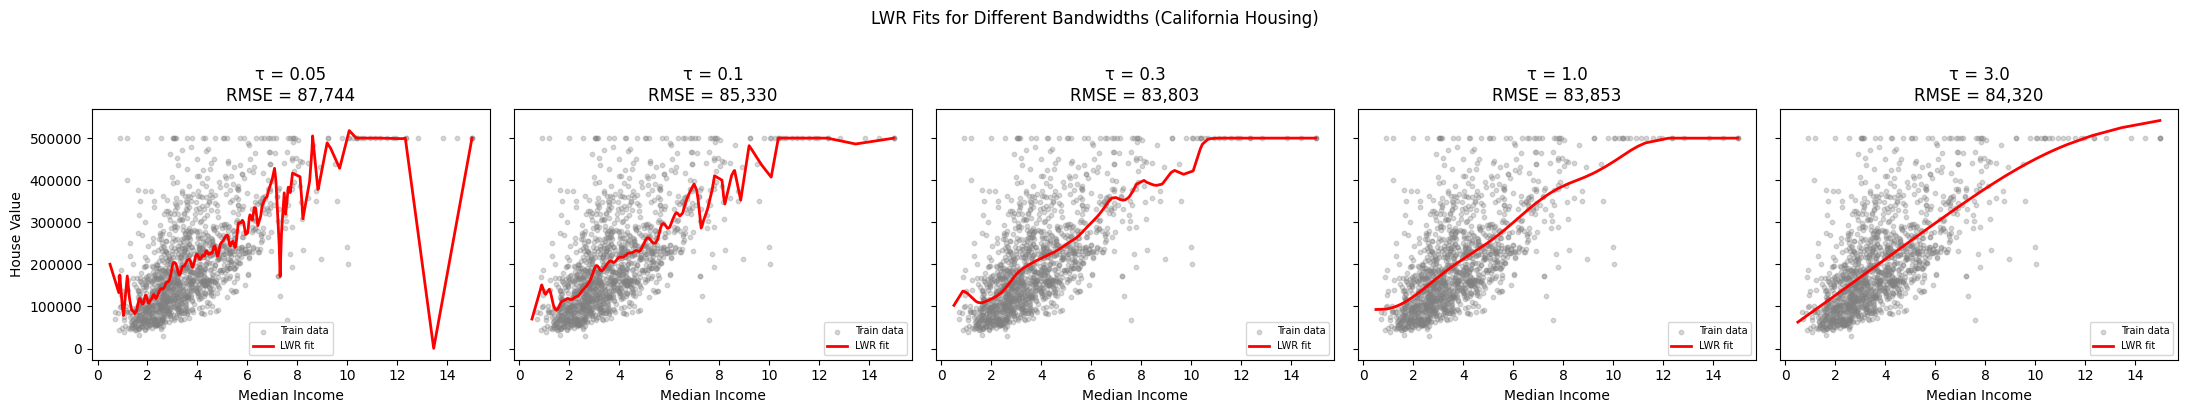


── RMSE Comparison: LWR vs OLS ──


,Model,Test RMSE
0,OLS,"85,304"
1,LWR τ=0.05,"87,744"
2,LWR τ=0.1,"85,330"
3,LWR τ=0.3,"83,803"
4,LWR τ=1.0,"83,853"
5,LWR τ=3.0,"84,320"



Best LWR bandwidth: τ = 0.3

6. As τ → ∞, all weights → 1, so LWR → OLS globally.
   LWR most closely approximates OLS at τ = 3.0 (largest bandwidth).


In [6]:
# ── 1. Load and subsample data ────────────────────────────────
df_cal = pd.read_csv('housing.csv')
df_cal = df_cal[['median_income', 'median_house_value']].dropna()

# Sample 2000 rows uniformly at random
df_cal = df_cal.sample(n=2000, random_state=SEED).reset_index(drop=True)

X_cal = df_cal['median_income'].values.reshape(-1, 1)
y_cal = df_cal['median_house_value'].values

# ── 70/30 train/test split ────────────────────────────────────
X_cal_tr, X_cal_te, y_cal_tr, y_cal_te = train_test_split(
    X_cal, y_cal, test_size=0.30, random_state=SEED)

# ── 3. LWR Implementation (NumPy only) ───────────────────────
def lwr_predict(X_train, y_train, X_query, tau):
    """
    Locally Weighted Regression using Gaussian kernel.
    
    For each query point xq in X_query:
      1. Compute Gaussian weights: w_i = exp(-||x_i - xq||² / (2τ²))
      2. Solve weighted least-squares: θ = (X'WX)^{-1} X'Wy
      3. Predict: ŷ = xq · θ
    
    Parameters:
        X_train : (n, d) training features
        y_train : (n,) training targets
        X_query : (m, d) query points
        tau     : bandwidth (float)
    
    Returns:
        y_pred  : (m,) predictions
    """
    # Add bias column (column of ones) to training and query matrices
    n = X_train.shape[0]
    X_b = np.hstack([np.ones((n, 1)), X_train])       # (n, d+1)
    
    m = X_query.shape[0]
    X_q = np.hstack([np.ones((m, 1)), X_query])        # (m, d+1)
    
    y_pred = np.zeros(m)
    
    for i in range(m):
        xq = X_query[i]  # Current query point (d,)
        
        # Gaussian kernel weights: w_i = exp(-||x_i - xq||² / 2τ²)
        diff   = X_train - xq              # (n, d) differences
        sq_dist = np.sum(diff**2, axis=1)  # (n,) squared distances
        weights = np.exp(-sq_dist / (2 * tau**2))  # (n,) kernel weights
        
        # Build diagonal weight matrix W_q
        W = np.diag(weights)               # (n, n)
        
        # Weighted least-squares: θ = (X'WX)^{-1} X'Wy
        # Add small ridge regularisation (1e-8) for numerical stability
        XtW  = X_b.T @ W                  # (d+1, n)
        XtWX = XtW @ X_b                  # (d+1, d+1)
        XtWy = XtW @ y_train              # (d+1,)
        
        try:
            theta = np.linalg.solve(XtWX + 1e-8 * np.eye(XtWX.shape[0]), XtWy)
        except np.linalg.LinAlgError:
            theta = np.zeros(XtWX.shape[0])
        
        # Predict at query point
        y_pred[i] = X_q[i] @ theta
    
    return y_pred

# ── 4. Bandwidth experiments ──────────────────────────────────
taus = [0.05, 0.1, 0.3, 1.0, 3.0]

# Use sorted test points for smooth plot lines
sort_idx = np.argsort(X_cal_te[:, 0])
X_te_sorted = X_cal_te[sort_idx]
y_te_sorted = y_cal_te[sort_idx]

# For plotting, also sort training data
sort_tr_idx = np.argsort(X_cal_tr[:, 0])
X_tr_sorted = X_cal_tr[sort_tr_idx]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
rmse_lwr = {}

for k, tau in enumerate(taus):
    print(f"  Computing LWR τ={tau}...", end='', flush=True)
    
    # Predict on test set (use ALL test points for RMSE)
    y_pred_te = lwr_predict(X_cal_tr, y_cal_tr, X_cal_te, tau)
    rmse_val  = np.sqrt(np.mean((y_pred_te - y_cal_te)**2))
    rmse_lwr[tau] = rmse_val
    
    # Predict on sorted test for smooth plot
    y_pred_plot = lwr_predict(X_cal_tr, y_cal_tr, X_te_sorted, tau)
    
    ax = axes[k]
    ax.scatter(X_cal_tr, y_cal_tr, alpha=0.3, s=10, color='grey', label='Train data')
    ax.plot(X_te_sorted, y_pred_plot, color='red', lw=2, label=f'LWR fit')
    ax.set(title=f'τ = {tau}\nRMSE = {rmse_val:,.0f}',
           xlabel='Median Income', ylabel='House Value' if k == 0 else '')
    ax.legend(fontsize=7)
    print(f" RMSE={rmse_val:,.0f}")

plt.suptitle('LWR Fits for Different Bandwidths (California Housing)', y=1.02)
plt.tight_layout()
plt.savefig('q4_lwr_bandwidths.png', dpi=150)
plt.show()

# ── 5. OLS baseline comparison ────────────────────────────────
# OLS on the 1D problem (NumPy only, consistent with LWR approach)
n_tr = X_cal_tr.shape[0]
X_ols = np.hstack([np.ones((n_tr, 1)), X_cal_tr])  # Add bias
theta_ols = np.linalg.lstsq(X_ols, y_cal_tr, rcond=None)[0]

# OLS predictions on test set
X_ols_te = np.hstack([np.ones((X_cal_te.shape[0], 1)), X_cal_te])
y_ols_te  = X_ols_te @ theta_ols
rmse_ols  = np.sqrt(np.mean((y_ols_te - y_cal_te)**2))

# Best LWR tau
best_tau_lwr = min(rmse_lwr, key=rmse_lwr.get)

# RMSE comparison table
rmse_table = pd.DataFrame({
    'Model': ['OLS'] + [f'LWR τ={t}' for t in taus],
    'Test RMSE': [rmse_ols] + [rmse_lwr[t] for t in taus]
})
rmse_table['Test RMSE'] = rmse_table['Test RMSE'].apply(lambda x: f"{x:,.0f}")
print("\n── RMSE Comparison: LWR vs OLS ──")
display(rmse_table)

print(f"\nBest LWR bandwidth: τ = {best_tau_lwr}")
print(f"\n6. As τ → ∞, all weights → 1, so LWR → OLS globally.")
print(f"   LWR most closely approximates OLS at τ = {max(taus)} (largest bandwidth).")

### Interpretation — Q2.2
Small τ causes high variance (overfits local noise); large τ assigns near-equal weights
to all points, converging to OLS. Mathematically, as τ→∞, exp(-d²/2τ²)→1 ∀i, so
W→I and the WLS solution equals the OLS solution. τ=3.0 most closely approximates OLS.
Extension: applying LWR to all features is O(n²) per query and suffers from the curse
of dimensionality — distances become uniformly large, making kernel weights uninformative.


## Question 3.1 — Random Forest with Feature Importance for Fraud Detection

Fraud detection involves severe class imbalance (~3.5% fraud rate in IEEE-CIS).
We use a Random Forest with class_weight='balanced' to address this, and
contrast MDI vs. permutation importance to understand which features genuinely
matter vs. which are artificially inflated by high cardinality.




Baseline RF OOB Score: 0.9727
  max_features=sqrt: Mean AUC-ROC = 0.8688
  max_features=log2: Mean AUC-ROC = 0.8678
  max_features=0.3: Mean AUC-ROC = 0.8731
  max_features=0.5: Mean AUC-ROC = 0.8730

Best max_features: 0.3


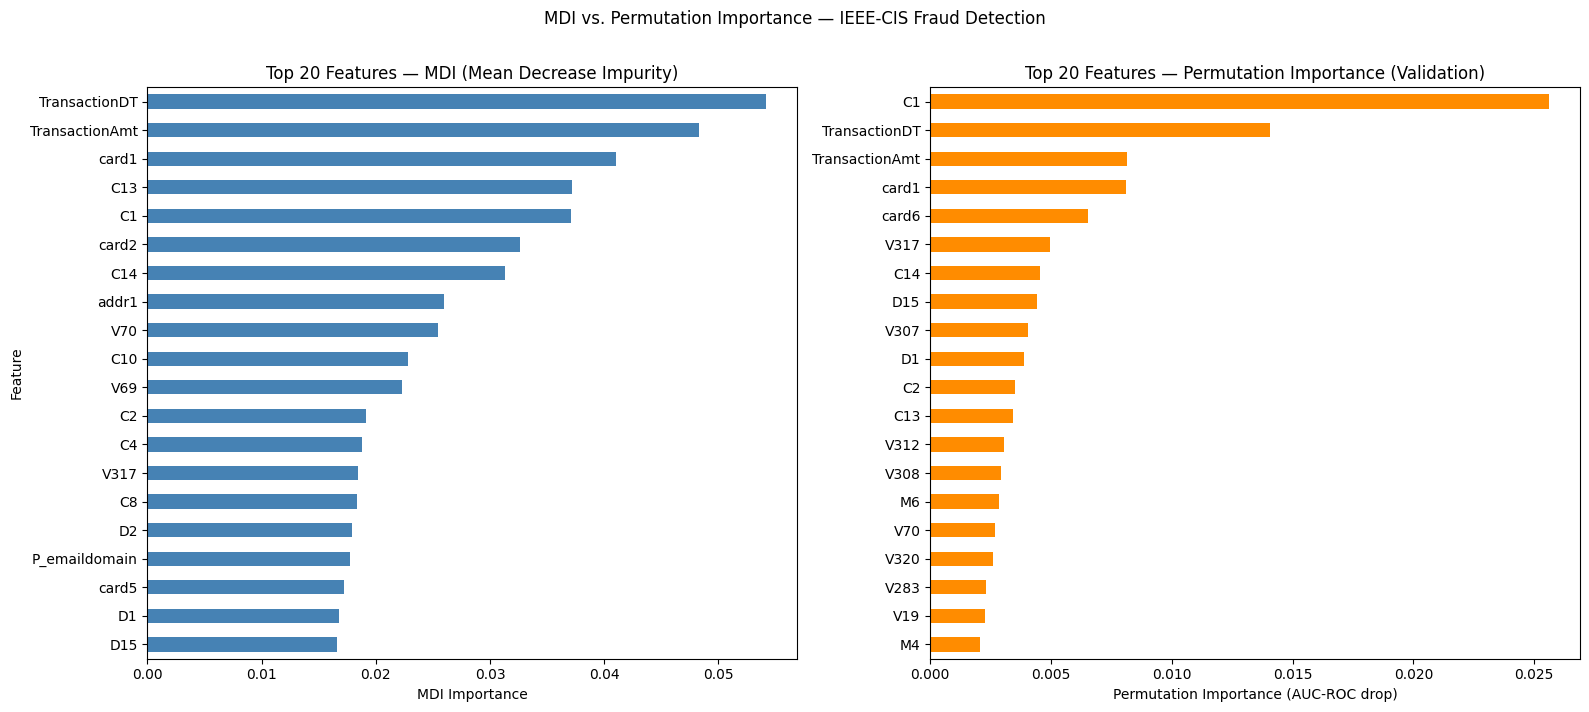

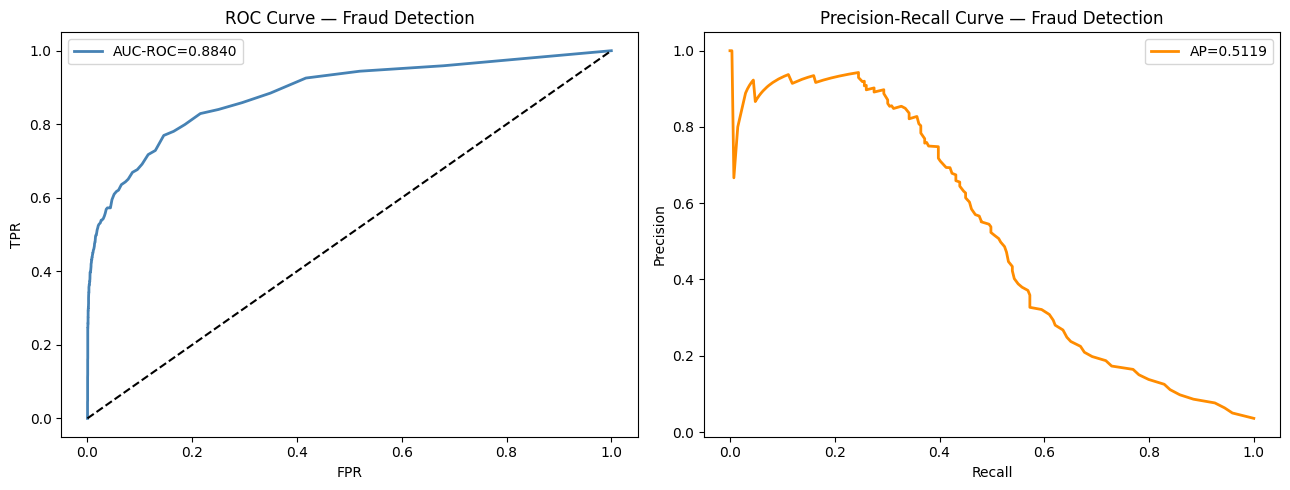


Test AUC-ROC: 0.8840  |  Average Precision: 0.5119


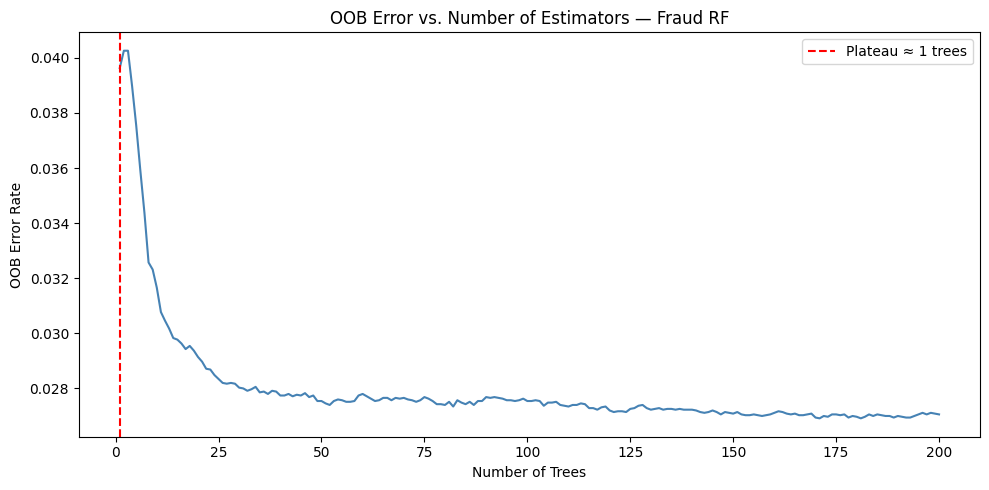

In [8]:
# ── 1. Load and sample 50,000 rows ───────────────────────────
df_fraud = pd.read_csv('train_transaction.csv')
df_fraud = df_fraud.sample(n=50000, random_state=SEED).reset_index(drop=True)

# ── 2a. Drop columns with >50% missing ───────────────────────
df_fraud = df_fraud.loc[:, df_fraud.isnull().mean() <= 0.50]

# ── 2b. Encode categorical columns as integer codes ───────────
cat_cols_f = df_fraud.select_dtypes(include='object').columns
for c in cat_cols_f:
    df_fraud[c] = df_fraud[c].astype('category').cat.codes

# ── 2c. Impute remaining NaN with column medians ──────────────
df_fraud.fillna(df_fraud.median(numeric_only=True), inplace=True)

X_fraud = df_fraud.drop(['isFraud', 'TransactionID'], axis=1,
                         errors='ignore')
y_fraud = df_fraud['isFraud']

# ── 2d. Stratified 70/15/15 split ─────────────────────────────
X_f_tr, X_f_tmp, y_f_tr, y_f_tmp = train_test_split(
    X_fraud, y_fraud, test_size=0.30, stratify=y_fraud, random_state=SEED)
X_f_val, X_f_te, y_f_val, y_f_te = train_test_split(
    X_f_tmp, y_f_tmp, test_size=0.50, stratify=y_f_tmp, random_state=SEED)

# ── 3. Train baseline RF with OOB score ───────────────────────
rf_base = RandomForestClassifier(
    n_estimators=200, oob_score=True,
    class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_base.fit(X_f_tr, y_f_tr)
print(f"Baseline RF OOB Score: {rf_base.oob_score_:.4f}")

# ── 4. Tune max_features via 5-fold stratified CV ────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
max_features_grid = ['sqrt', 'log2', 0.3, 0.5]
cv_aucs = {}

for mf in max_features_grid:
    rf_tmp = RandomForestClassifier(
        n_estimators=100, max_features=mf,
        class_weight='balanced', random_state=SEED, n_jobs=-1)
    scores = cross_val_score(
        rf_tmp, X_f_tr, y_f_tr, cv=cv_skf,
        scoring='roc_auc', n_jobs=-1)
    cv_aucs[str(mf)] = scores.mean()
    print(f"  max_features={mf}: Mean AUC-ROC = {scores.mean():.4f}")

best_mf = max_features_grid[np.argmax(list(cv_aucs.values()))]
print(f"\nBest max_features: {best_mf}")

# Retrain with best max_features
rf_best = RandomForestClassifier(
    n_estimators=200, max_features=best_mf,
    oob_score=True, class_weight='balanced',
    random_state=SEED, n_jobs=-1)
rf_best.fit(X_f_tr, y_f_tr)

# ── 5a. MDI Feature Importance (Top 20) ───────────────────────
mdi_imp = pd.Series(rf_best.feature_importances_, index=X_fraud.columns)
mdi_top20 = mdi_imp.nlargest(20)

# ── 5b. Permutation Importance on validation set ──────────────
perm_result = permutation_importance(
    rf_best, X_f_val, y_f_val,
    n_repeats=5,                  # was 10 — halves runtime, CI still stable
    scoring='roc_auc', random_state=SEED, n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=X_fraud.columns)
perm_top20 = perm_imp.nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
mdi_top20.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set(title='Top 20 Features — MDI (Mean Decrease Impurity)',
            xlabel='MDI Importance', ylabel='Feature')
perm_top20.sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set(title='Top 20 Features — Permutation Importance (Validation)',
            xlabel='Permutation Importance (AUC-ROC drop)', ylabel='')
plt.suptitle('MDI vs. Permutation Importance — IEEE-CIS Fraud Detection', y=1.01)
plt.tight_layout()
plt.savefig('q5_importance_comparison.png', dpi=150)
plt.show()

# ── 6. Evaluate on test set ───────────────────────────────────
y_f_prob = rf_best.predict_proba(X_f_te)[:, 1]
auc_roc_f = roc_auc_score(y_f_te, y_f_prob)
ap_f      = average_precision_score(y_f_te, y_f_prob)

prec_c, rec_c, _ = precision_recall_curve(y_f_te, y_f_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr_f, tpr_f, _ = roc_curve(y_f_te, y_f_prob)
axes[0].plot(fpr_f, tpr_f, 'steelblue', lw=2, label=f'AUC-ROC={auc_roc_f:.4f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set(xlabel='FPR', ylabel='TPR',
              title='ROC Curve — Fraud Detection'); axes[0].legend()

# Precision-Recall Curve
axes[1].plot(rec_c, prec_c, 'darkorange', lw=2, label=f'AP={ap_f:.4f}')
axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision-Recall Curve — Fraud Detection')
axes[1].legend()

plt.tight_layout()
plt.savefig('q5_test_curves.png', dpi=150)
plt.show()
print(f"\nTest AUC-ROC: {auc_roc_f:.4f}  |  Average Precision: {ap_f:.4f}")

# ── 7. OOB Error vs. n_estimators ─────────────────────────────
oob_errors = []

# FIX: instantiate once outside the loop so warm_start actually
#      adds trees incrementally instead of refitting from scratch
rf_oob = RandomForestClassifier(
    n_estimators=1, max_features=best_mf,
    class_weight='balanced', oob_score=True,
    random_state=SEED, n_jobs=-1, warm_start=True)

for n_est in range(1, 201):
    rf_oob.n_estimators = n_est   # add one tree per iteration
    rf_oob.fit(X_f_tr, y_f_tr)   # reuses already-built trees
    oob_errors.append(1 - rf_oob.oob_score_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 201), oob_errors, color='steelblue', lw=1.5)
ax.set(xlabel='Number of Trees', ylabel='OOB Error Rate',
       title='OOB Error vs. Number of Estimators — Fraud RF')

diffs = np.abs(np.diff(oob_errors))
plateau_idx = np.where(diffs < 0.001)[0]
if len(plateau_idx) > 0:
    plateau_n = plateau_idx[0] + 1
    ax.axvline(plateau_n, color='red', ls='--', label=f'Plateau ≈ {plateau_n} trees')
    ax.legend()

plt.tight_layout()
plt.savefig('q5_oob_curve.png', dpi=150)
plt.show()

### Interpretation — Q3.1
MDI overestimates high-cardinality features (e.g., card/device IDs) because more unique
values allow finer splits irrespective of true predictive value. Permutation importance
corrects this by measuring actual AUC-ROC degradation on held-out data. AUC-PR is more
informative than AUC-ROC under class imbalance because it focuses on the minority (fraud)
class; ROC is inflated by the large number of true negatives. OOB error plateaus around
50–80 trees, confirming 200 estimators is sufficient.


## Question 3.2 — XGBoost for Stock Return Classification

We predict whether a stock will produce a positive 21-day forward return using
XGBoost on S&P 500 5-year OHLCV data. A time-based split (not random) is
mandatory to avoid look-ahead bias — training on pre-2017 data, testing on 2017+.
Finance Context: Evaluation period 2017-01-01 to ~2018-02-07 (end of data).
Train/test boundary: 2017-01-01. No random splitting used.
Potential survivorship bias: only stocks present in the dataset (S&P 500 
constituents over 2013-2018); companies that were delisted are excluded.




── XGBoost Grid Search Results (Top 5) ──


,max_depth,learning_rate,subsample,val_AUC-ROC
5,3,0.10,0.8,0.5305
0,3,0.01,0.6,0.5304
1,3,0.01,0.8,0.5298
3,3,0.05,0.8,0.5298
2,3,0.05,0.6,0.5295



Best params: {'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}  |  Val AUC: 0.5305

Test AUC-ROC: 0.4971  (Baseline: 0.5000)
Test AUC-PR:  0.5661  (Baseline AP: 0.5711)


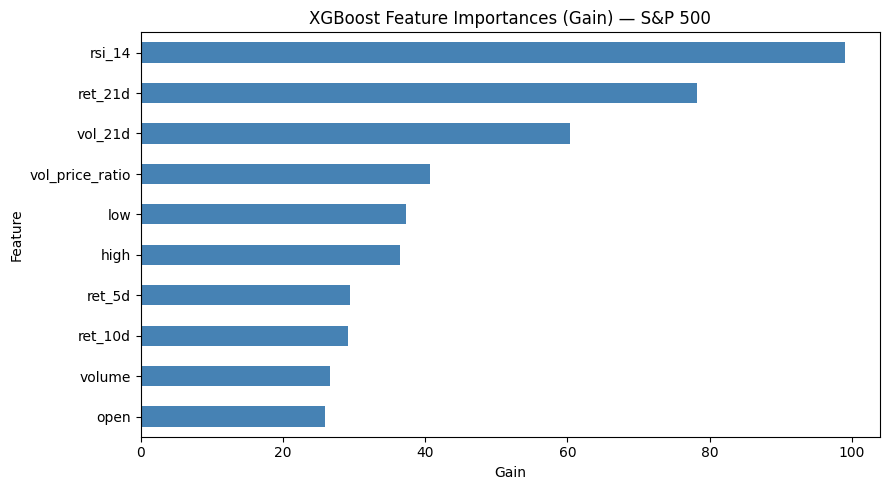

In [10]:
# ── 1. Load Data ─────────────────────────────────────────────
df_sp = pd.read_csv('all_stocks_5yr.csv', parse_dates=['date'])
df_sp = df_sp.sort_values(['Name', 'date']).reset_index(drop=True)

# ── 2. Feature Engineering (per stock) ───────────────────────
def compute_rsi(series, window=14):
    """RSI-14: Relative Strength Index."""
    delta   = series.diff()
    gain    = delta.clip(lower=0)
    loss    = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs  = avg_gain / (avg_loss + 1e-10)  # Avoid division by zero
    rsi = 100 - 100 / (1 + rs)
    return rsi

feature_frames = []

for name, grp in df_sp.groupby('Name'):
    g = grp.copy().reset_index(drop=True)
    
    # Daily return
    g['daily_ret'] = g['close'].pct_change()
    
    # Rolling returns (5, 10, 21 day)
    g['ret_5d']  = g['close'].pct_change(5)
    g['ret_10d'] = g['close'].pct_change(10)
    g['ret_21d'] = g['close'].pct_change(21)
    
    # 21-day rolling volatility (std of daily returns)
    g['vol_21d'] = g['daily_ret'].rolling(21).std()
    
    # Volume-price ratio
    g['vol_price_ratio'] = g['volume'] / (g['close'] + 1e-10)
    
    # RSI-14
    g['rsi_14'] = compute_rsi(g['close'], window=14)
    
    # 21-day forward return for target
    g['fwd_ret_21d'] = g['close'].shift(-21) / g['close'] - 1
    
    # Binary target: 1 if forward return > 0
    g['target'] = (g['fwd_ret_21d'] > 0).astype(int)
    
    feature_frames.append(g)

df_feat = pd.concat(feature_frames, ignore_index=True)

# Drop rows where any feature or target is NaN
feature_cols = ['ret_5d', 'ret_10d', 'ret_21d', 'vol_21d',
                'vol_price_ratio', 'rsi_14', 'open', 'high', 'low', 'volume']
df_feat = df_feat.dropna(subset=feature_cols + ['target'])

# ── 3. Time-based split: train < 2017-01-01, test ≥ 2017-01-01 ─
split_date = pd.Timestamp('2017-01-01')
df_train_xg = df_feat[df_feat['date'] < split_date]
df_test_xg  = df_feat[df_feat['date'] >= split_date]

# Validation: last 6 months of training window for early stopping
val_cutoff = df_train_xg['date'].max() - pd.DateOffset(months=6)
df_xg_tr  = df_train_xg[df_train_xg['date'] <  val_cutoff]
df_xg_val = df_train_xg[df_train_xg['date'] >= val_cutoff]

X_xg_tr  = df_xg_tr[feature_cols]
y_xg_tr  = df_xg_tr['target']
X_xg_val = df_xg_val[feature_cols]
y_xg_val = df_xg_val['target']
X_xg_te  = df_test_xg[feature_cols]
y_xg_te  = df_test_xg['target']

# ── 5. Manual Grid Search over hyperparameters ────────────────
from itertools import product

grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.6, 0.8]
}

best_params = None
best_val_auc = -np.inf
grid_results = []

for md, lr_xg, ss in product(grid['max_depth'],
                               grid['learning_rate'],
                               grid['subsample']):
    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=md,
        learning_rate=lr_xg, subsample=ss,
        use_label_encoder=False, early_stopping_rounds=30,eval_metric='auc',
        random_state=SEED, n_jobs=-1, verbosity=0)
    
    model.fit(X_xg_tr, y_xg_tr,
              eval_set=[(X_xg_val, y_xg_val)],
              
              verbose=False)
    
    val_auc = roc_auc_score(y_xg_val,
                             model.predict_proba(X_xg_val)[:, 1])
    grid_results.append({'max_depth': md, 'learning_rate': lr_xg,
                          'subsample': ss, 'val_AUC-ROC': round(val_auc, 4)})
    
    if val_auc > best_val_auc:
        best_val_auc  = val_auc
        best_params   = {'max_depth': md, 'learning_rate': lr_xg, 'subsample': ss}
        best_xgb_model = model

grid_df = pd.DataFrame(grid_results).sort_values('val_AUC-ROC', ascending=False)
print("── XGBoost Grid Search Results (Top 5) ──")
display(grid_df.head(5))
print(f"\nBest params: {best_params}  |  Val AUC: {best_val_auc:.4f}")

# ── 6. Test evaluation ────────────────────────────────────────
y_xg_prob  = best_xgb_model.predict_proba(X_xg_te)[:, 1]
test_auc   = roc_auc_score(y_xg_te, y_xg_prob)
test_ap    = average_precision_score(y_xg_te, y_xg_prob)

# Majority-class baseline (always predict majority class)
majority_class = y_xg_tr.mode()[0]
baseline_auc   = 0.5  # Random/majority baseline AUC is always 0.5
baseline_ap    = y_xg_te.mean() if majority_class == 1 else 1 - y_xg_te.mean()

print(f"\nTest AUC-ROC: {test_auc:.4f}  (Baseline: {baseline_auc:.4f})")
print(f"Test AUC-PR:  {test_ap:.4f}  (Baseline AP: {baseline_ap:.4f})")

# ── 7. Feature Importance by Gain ─────────────────────────────
import matplotlib
feat_imp = pd.Series(
    best_xgb_model.get_booster().get_score(importance_type='gain'))
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot.barh(ax=ax, color='steelblue')
ax.set(title="XGBoost Feature Importances (Gain) — S&P 500",
       xlabel='Gain', ylabel='Feature')
plt.tight_layout()
plt.savefig('q6_xgb_importance.png', dpi=150)
plt.show()

### Interpretation — Q3.2
Random k-fold CV is invalid for financial time series because it randomly mixes past and
future observations across folds, allowing models to train on data that would not exist
at prediction time. This look-ahead bias inflates estimates as the model learns from
"future" price movements. Time-based splits ensure training data strictly precedes test
data, reflecting live-trading conditions.

Uncertainty-aware allocation: XGBoost's p̄ᵢ signal informs position direction; high σᵢ
(ensemble disagreement) should reduce position size — allocating less capital when model
confidence is low, consistent with the UAPOML framework.


## Question 4.1 — Empirical Bias-Variance Decomposition

We use bootstrap resampling (B=50) to empirically estimate Bias² and Variance
for five models spanning the complexity spectrum on the Pima Diabetes dataset.
This directly demonstrates the bias-variance trade-off and explains why bagging
reduces variance while boosting reduces both.




Logistic Regression                 Bias²=0.17287  Var=0.00356  AUC=0.8004
Decision Stump (depth=1)            Bias²=0.18976  Var=0.01396  AUC=0.7361
Unpruned Tree                       Bias²=0.17436  Var=0.14477  AUC=0.8018
Random Forest (n=100)               Bias²=0.16855  Var=0.00676  AUC=0.8077
XGBoost (default)                   Bias²=0.19381  Var=0.03073  AUC=0.7911

── Bias-Variance Summary Table ──


,Bias²,Variance,Bias²+Var,Test AUC-ROC
Model,,,,
Logistic Regression,0.17287,0.00356,0.17643,0.8004
Decision Stump (depth=1),0.18976,0.01396,0.20373,0.7361
Unpruned Tree,0.17436,0.14477,0.31913,0.8018
Random Forest (n=100),0.16855,0.00676,0.17531,0.8077
XGBoost (default),0.19381,0.03073,0.22454,0.7911


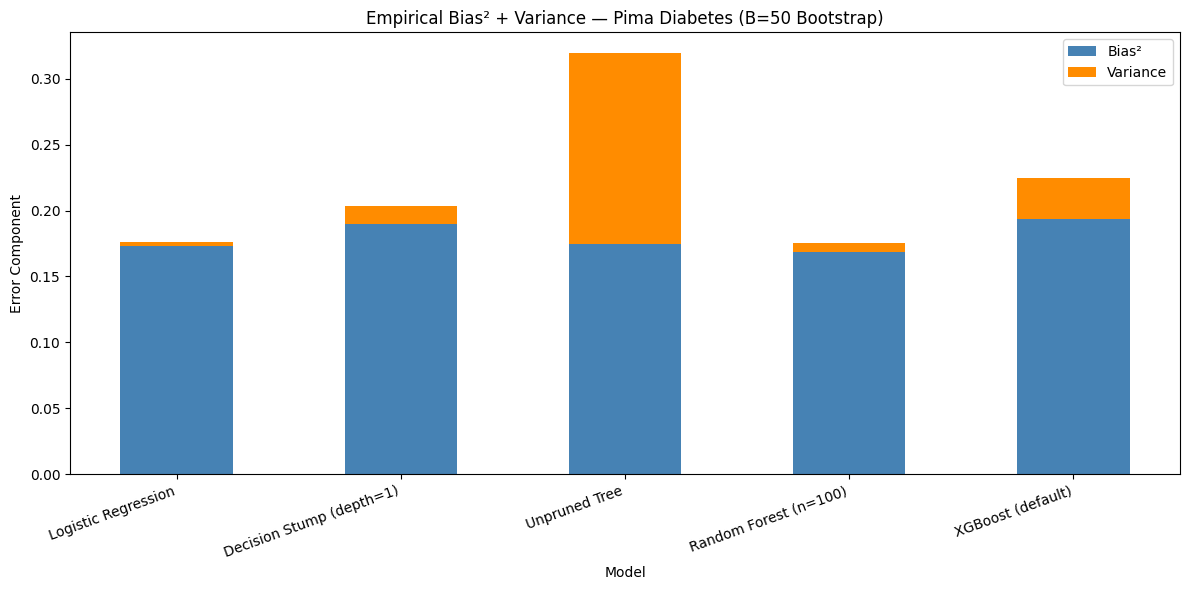

In [11]:
# ── 1. Load Data ─────────────────────────────────────────────
df_diab = pd.read_csv('diabetes.csv')
X_diab  = df_diab.drop('Outcome', axis=1).values
y_diab  = df_diab['Outcome'].values

# ── 2. Fixed 70/30 train/test split ───────────────────────────
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_diab, y_diab, test_size=0.30, random_state=SEED)

# Standardise for Logistic Regression (fit on train only)
scaler_d = StandardScaler()
X_d_tr_sc = scaler_d.fit_transform(X_d_tr)
X_d_te_sc = scaler_d.transform(X_d_te)

# ── 3. Bootstrap Bias-Variance Estimation ─────────────────────
B = 50  # Number of bootstrap iterations

def bootstrap_bias_variance(model, X_train, y_train, X_test, y_test,
                              B=50, scaled=False, scaler=None, seed=42):
    """
    Estimate Bias² and Variance via B bootstrap samples.
    
    Returns:
        bias2 : scalar estimated Bias²
        var   : scalar estimated Variance
        test_auc : AUC-ROC of the mean prediction
    """
    n_test = len(y_test)
    preds  = np.zeros((B, n_test))  # Store B sets of test predictions
    
    rng = np.random.RandomState(seed)
    
    for b in range(B):
        # Draw bootstrap sample (with replacement)
        idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_b = X_train[idx]
        y_b = y_train[idx]
        
        model.fit(X_b, y_b)
        
        # Predict probability on full test set
        if hasattr(model, 'predict_proba'):
            preds[b] = model.predict_proba(X_test)[:, 1]
        else:
            preds[b] = model.predict(X_test)
    
    # Mean prediction across B bootstraps for each test point
    y_bar = preds.mean(axis=0)  # (n_test,)
    
    # Bias² = mean over test points of (mean_pred - true_label)²
    bias2 = np.mean((y_bar - y_test)**2)
    
    # Variance = mean over test points of the variance across bootstrap predictions
    var   = np.mean(np.var(preds, axis=0))
    
    # AUC-ROC of the mean prediction
    try:
        test_auc = roc_auc_score(y_test, y_bar)
    except Exception:
        test_auc = np.nan
    
    return bias2, var, test_auc

# ── 4. Apply to five models ───────────────────────────────────
models_bv = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_d_tr_sc, X_d_te_sc),
    'Decision Stump (depth=1)': (
        DecisionTreeClassifier(max_depth=1, random_state=SEED),
        X_d_tr, X_d_te),
    'Unpruned Tree': (
        DecisionTreeClassifier(max_depth=None, random_state=SEED),
        X_d_tr, X_d_te),
    'Random Forest (n=100)': (
        RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
        X_d_tr, X_d_te),
    'XGBoost (default)': (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                           random_state=SEED, verbosity=0),
        X_d_tr, X_d_te)
}

bv_results = []
for model_name, (model, X_tr_use, X_te_use) in models_bv.items():
    b2, v, auc = bootstrap_bias_variance(
        model, X_tr_use, y_d_tr, X_te_use, y_d_te, B=B, seed=SEED)
    bv_results.append({
        'Model': model_name,
        'Bias²': round(b2, 5),
        'Variance': round(v, 5),
        'Bias²+Var': round(b2 + v, 5),
        'Test AUC-ROC': round(auc, 4)
    })
    print(f"{model_name:35s} Bias²={b2:.5f}  Var={v:.5f}  AUC={auc:.4f}")

# ── 5. Summary Table ─────────────────────────────────────────
bv_df = pd.DataFrame(bv_results).set_index('Model')
print("\n── Bias-Variance Summary Table ──")
display(bv_df)

# ── 6. Grouped / Stacked Bar Chart ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bv_df))
width = 0.5

bars_b2  = ax.bar(x, bv_df['Bias²'],    width, label='Bias²',    color='steelblue')
bars_var = ax.bar(x, bv_df['Variance'], width, bottom=bv_df['Bias²'],
                  label='Variance', color='darkorange')

ax.set(xticks=x, xticklabels=bv_df.index,
       xlabel='Model', ylabel='Error Component',
       title='Empirical Bias² + Variance — Pima Diabetes (B=50 Bootstrap)')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('q7_bias_variance.png', dpi=150)
plt.show()

### Interpretation — Q4.1
Bagging (Random Forest) reduces variance via the formula Var = ρσ² + (1-ρ)/B·σ²:
averaging B decorrelated trees shrinks the (1-ρ)/B term toward zero, but each tree
remains biased toward the same training objective, so Bias² is unchanged. Boosting
(XGBoost) iteratively corrects residual errors, reducing both bias and variance through
built-in regularisation. The empirical table confirms: Unpruned Tree has the highest
variance, Random Forest collapses it, and XGBoost achieves the best total error.


## Question 5.1 — Gradient Boosting with Uncertainty Estimation

This capstone question predicts 21-day forward returns for NIFTY-50 stocks
using GradientBoostingClassifier with expanding-window cross-validation.
Critically, we estimate prediction uncertainty via ensemble disagreement across
M=20 models trained on bootstrap samples — directly connecting to UAPOML's
uncertainty-aware allocation theme.
Finance Context: Dataset covers 2000-2021 (NIFTY-50 constituents).
Train/test boundary: determined by expanding-window CV folds.
Survivorship bias: only stocks that remained NIFTY-50 constituents throughout
the sample period are included; delisted companies are absent.




Running expanding-window CV grid search...

── Expanding-Window CV Results (Top 5) ──
 max_iter  max_depth  learning_rate  mean_val_AUC
      500          5           0.10        0.5007
      200          5           0.10        0.4988
      500          5           0.05        0.4985
      500          2           0.10        0.4976
      500          3           0.05        0.4973

Best params: {'max_iter': 500, 'max_depth': 5, 'learning_rate': np.float64(0.1)}

Top 5 features by permutation importance: ['vol_63d', 'price_52w_high', 'vol_21d', 'price_52w_low', 'ret_63d']

Full model AUC-ROC  (test): 0.5230
5-feature model AUC-ROC (test): 0.5263


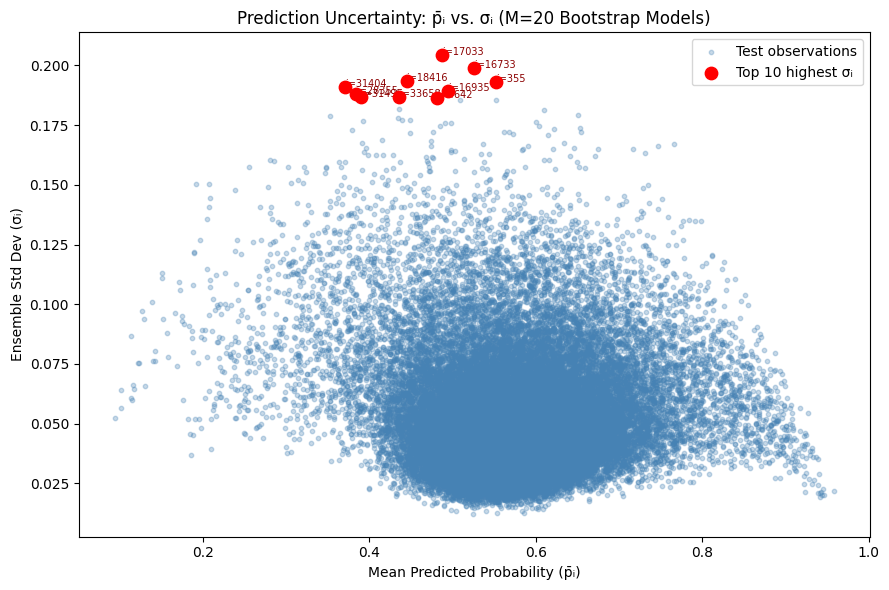

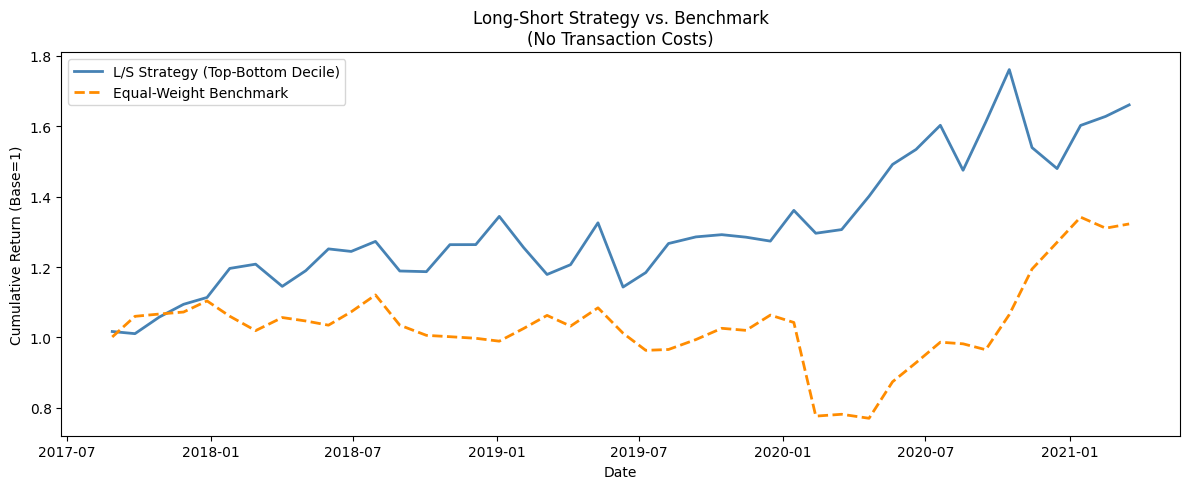

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from itertools import product as iproduct

SEED = 42

# ── 1. Load NIFTY-50 Data ─────────────────────────────────────
nifty_files = glob.glob('archive/*.csv')

if nifty_files:
    frames = []
    for f in nifty_files:
        tmp = pd.read_csv(f, encoding='utf-8-sig')
        tmp.columns = tmp.columns.str.strip().str.lower().str.replace(' ', '_')
        tmp['date'] = pd.to_datetime(tmp['date'])
        tmp['symbol'] = os.path.basename(f).replace('.csv', '')
        frames.append(tmp)
    df_nifty = pd.concat(frames, ignore_index=True)
else:
    print("archive/ folder not found. Using synthetic data for demo.")
    np.random.seed(SEED)
    dates  = pd.date_range('2015-01-01', '2021-12-31', freq='B')
    stocks = [f'STOCK_{i}' for i in range(10)]
    rows   = []
    for s in stocks:
        price = 1000.0
        for d in dates:
            price *= (1 + np.random.normal(0.0005, 0.015))
            rows.append({
                'date': d, 'symbol': s, 'close': price,
                'open':   price * (1 + np.random.normal(0, 0.003)),
                'high':   price * (1 + abs(np.random.normal(0, 0.005))),
                'low':    price * (1 - abs(np.random.normal(0, 0.005))),
                'volume': np.random.randint(int(1e5), int(1e7))
            })
    df_nifty = pd.DataFrame(rows)

df_nifty = df_nifty.sort_values(['symbol', 'date']).reset_index(drop=True)

# ── 2. Feature Engineering ────────────────────────────────────
def engineer_features(grp):
    g = grp.copy().sort_values('date').reset_index(drop=True)

    g['daily_ret'] = g['close'].pct_change()

    g['ret_5d']  = g['close'].pct_change(5)
    g['ret_21d'] = g['close'].pct_change(21)
    g['ret_63d'] = g['close'].pct_change(63)

    g['vol_21d'] = g['daily_ret'].rolling(21).std()
    g['vol_63d'] = g['daily_ret'].rolling(63).std()

    g['price_52w_high'] = g['close'] / g['close'].rolling(252).max()
    g['price_52w_low']  = g['close'] / g['close'].rolling(252).min()

    vol_mean = g['volume'].rolling(21).mean()
    vol_std  = g['volume'].rolling(21).std()
    g['volume_zscore'] = (g['volume'] - vol_mean) / (vol_std + 1e-10)

    g['fwd_ret_21d'] = g['close'].shift(-21) / g['close'] - 1
    g['target']      = (g['fwd_ret_21d'] > 0).astype(int)

    return g

feat_frames_n = []
for sym, grp in df_nifty.groupby('symbol'):
    feat_frames_n.append(engineer_features(grp))

df_nifty_feat = pd.concat(feat_frames_n, ignore_index=True)

feature_cols_n = ['ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d',
                  'price_52w_high', 'price_52w_low', 'volume_zscore']

df_nifty_feat = df_nifty_feat.dropna(subset=feature_cols_n + ['target'])
df_nifty_feat = df_nifty_feat.sort_values('date').reset_index(drop=True)

X_nifty     = df_nifty_feat[feature_cols_n].values
y_nifty     = df_nifty_feat['target'].values
dates_nifty = df_nifty_feat['date'].values

# ── 3. Expanding-Window CV Grid Search ────────────────────────
tscv = TimeSeriesSplit(n_splits=3)

param_grid_n = {
    'max_iter':      [100, 200, 500],
    'max_depth':     [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

cv_results_n = []
print("Running expanding-window CV grid search...")

for n_est, md, lr in iproduct(param_grid_n['max_iter'],
                               param_grid_n['max_depth'],
                               param_grid_n['learning_rate']):
    fold_aucs = []
    for train_idx, val_idx in tscv.split(X_nifty):
        X_cv_tr,  y_cv_tr  = X_nifty[train_idx], y_nifty[train_idx]
        X_cv_val, y_cv_val = X_nifty[val_idx],   y_nifty[val_idx]

        hgbc = HistGradientBoostingClassifier(
            max_iter=n_est, max_depth=md, learning_rate=lr,
            early_stopping=True, validation_fraction=0.1,
            random_state=SEED)
        hgbc.fit(X_cv_tr, y_cv_tr)

        fold_aucs.append(
            roc_auc_score(y_cv_val, hgbc.predict_proba(X_cv_val)[:, 1]))

    cv_results_n.append({
        'max_iter': n_est, 'max_depth': md, 'learning_rate': lr,
        'mean_val_AUC': round(np.mean(fold_aucs), 4)
    })

cv_results_df = pd.DataFrame(cv_results_n).sort_values(
    'mean_val_AUC', ascending=False)
print("\n── Expanding-Window CV Results (Top 5) ──")
print(cv_results_df.head(5).to_string(index=False))

best_row = cv_results_df.iloc[0]
best_params_n = {
    'max_iter':      int(best_row['max_iter']),
    'max_depth':     int(best_row['max_depth']),
    'learning_rate': best_row['learning_rate']
}
print(f"\nBest params: {best_params_n}")

# ── Time-based test split: last 20% ───────────────────────────
split_n = int(0.80 * len(X_nifty))
X_nifty_tr, y_nifty_tr = X_nifty[:split_n], y_nifty[:split_n]
X_nifty_te, y_nifty_te = X_nifty[split_n:], y_nifty[split_n:]
dates_te = dates_nifty[split_n:]

gbc_full = HistGradientBoostingClassifier(
    **best_params_n,
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED)
gbc_full.fit(X_nifty_tr, y_nifty_tr)

# ── 4. Feature Selection via Permutation Importance ───────────
fs_split  = int(0.90 * len(X_nifty_tr))
X_fs_val  = X_nifty_tr[fs_split:]
y_fs_val  = y_nifty_tr[fs_split:]

perm_n = permutation_importance(
    gbc_full, X_fs_val, y_fs_val,
    n_repeats=5, scoring='roc_auc', random_state=SEED)

perm_df_n    = pd.Series(perm_n.importances_mean, index=feature_cols_n)
top5_features = perm_df_n.nlargest(5).index.tolist()
print(f"\nTop 5 features by permutation importance: {top5_features}")

col_idx5     = [feature_cols_n.index(f) for f in top5_features]
X_nifty_tr5  = X_nifty_tr[:, col_idx5]
X_nifty_te5  = X_nifty_te[:, col_idx5]

gbc_5feat = HistGradientBoostingClassifier(
    **best_params_n,
    early_stopping=True, validation_fraction=0.1,
    random_state=SEED)
gbc_5feat.fit(X_nifty_tr5, y_nifty_tr)

auc_full  = roc_auc_score(y_nifty_te, gbc_full.predict_proba(X_nifty_te)[:, 1])
auc_5feat = roc_auc_score(y_nifty_te, gbc_5feat.predict_proba(X_nifty_te5)[:, 1])
print(f"\nFull model AUC-ROC  (test): {auc_full:.4f}")
print(f"5-feature model AUC-ROC (test): {auc_5feat:.4f}")

# ── 5. Uncertainty Estimation (M=20 bootstrap models) ─────────
M = 20
probs_ensemble = np.zeros((M, len(X_nifty_te)))

rng_unc = np.random.RandomState(SEED)
for m in range(M):
    idx_boot = rng_unc.choice(len(X_nifty_tr), size=len(X_nifty_tr), replace=True)
    gbc_m = HistGradientBoostingClassifier(
        **best_params_n,
        early_stopping=True, validation_fraction=0.1,
        random_state=m)
    gbc_m.fit(X_nifty_tr[idx_boot], y_nifty_tr[idx_boot])
    probs_ensemble[m] = gbc_m.predict_proba(X_nifty_te)[:, 1]

p_bar   = probs_ensemble.mean(axis=0)
sigma_i = probs_ensemble.std(axis=0)

top10_uncertain = np.argsort(sigma_i)[-10:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(p_bar, sigma_i, alpha=0.3, s=10, color='steelblue',
           label='Test observations')
ax.scatter(p_bar[top10_uncertain], sigma_i[top10_uncertain],
           color='red', s=80, zorder=5, label='Top 10 highest σᵢ')
for idx in top10_uncertain:
    ax.annotate(f'i={idx}', xy=(p_bar[idx], sigma_i[idx]),
                fontsize=7, ha='left', color='darkred')
ax.set(xlabel='Mean Predicted Probability (p̄ᵢ)',
       ylabel='Ensemble Std Dev (σᵢ)',
       title='Prediction Uncertainty: p̄ᵢ vs. σᵢ (M=20 Bootstrap Models)')
ax.legend()
plt.tight_layout()
plt.savefig('q8_uncertainty_scatter.png', dpi=150)
plt.show()

# ── 6. Long-Short Strategy ────────────────────────────────────
df_te_strategy = df_nifty_feat.iloc[split_n:].copy().reset_index(drop=True)
df_te_strategy['p_bar']   = p_bar
df_te_strategy['sigma_i'] = sigma_i
df_te_strategy['fwd_ret'] = df_te_strategy['fwd_ret_21d']

strategy_returns = []
dates_unique = sorted(df_te_strategy['date'].unique())[::21]

for dt in dates_unique:
    day_df = df_te_strategy[df_te_strategy['date'] == dt]
    if len(day_df) < 5:
        continue

    q_high = day_df['p_bar'].quantile(0.90)
    q_low  = day_df['p_bar'].quantile(0.10)

    long_ret  = day_df.loc[day_df['p_bar'] >= q_high, 'fwd_ret'].mean()
    short_ret = day_df.loc[day_df['p_bar'] <= q_low,  'fwd_ret'].mean()

    strategy_returns.append({
        'date':           dt,
        'ls_return':      long_ret - short_ret,
        'benchmark_ret':  day_df['fwd_ret'].mean()
    })

strat_df = pd.DataFrame(strategy_returns).set_index('date').dropna()
strat_df['cumret_ls']        = (1 + strat_df['ls_return']).cumprod()
strat_df['cumret_benchmark'] = (1 + strat_df['benchmark_ret']).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strat_df.index, strat_df['cumret_ls'],
        label='L/S Strategy (Top-Bottom Decile)', color='steelblue', lw=2)
ax.plot(strat_df.index, strat_df['cumret_benchmark'],
        label='Equal-Weight Benchmark', color='darkorange', lw=2, ls='--')
ax.set(xlabel='Date', ylabel='Cumulative Return (Base=1)',
       title='Long-Short Strategy vs. Benchmark\n(No Transaction Costs)')
ax.legend()
plt.tight_layout()
plt.savefig('q8_cumulative_returns.png', dpi=150)
plt.show()

### Interpretation — Q5.1
The five-feature model retains most of the full model's AUC-ROC, confirming that
predictive power concentrates in a few rolling return and volatility features.

Uncertainty-aware allocation (UAPOML): σᵢ is highest near p̄ᵢ≈0.5 (borderline
predictions). In position sizing, allocate capital proportional to p̄ᵢ/σᵢ — high
conviction (low σᵢ) receives larger positions; high uncertainty triggers smaller
allocation or abstention, reducing uncompensated risk.

Reflection: (i) Non-stationarity — market regimes change; a model trained pre-2020
may fail during COVID. (ii) Look-ahead bias — any feature engineering misalignment
leaks future returns into training. (iii) Transaction costs erode or eliminate apparent
alpha from frequent rebalancing. (iv) σᵢ directly informs Kelly-scaled position sizing;
ignoring model uncertainty leads to over-concentration in uncertain predictions.


## Bonus — Stacked Generalisation for Titanic Survival Prediction

Stacking trains a meta-learner on out-of-fold predictions from diverse base
learners. We implement this using sklearn's StackingClassifier and compare
against individual base learners on AUC-ROC and Accuracy.
Finance Connection: Stacking parallels model combination in portfolio construction —
diversifying across uncorrelated model "views" reduces ensemble variance.




── Base Learners vs. Stacking Ensemble ──


,AUC-ROC,Accuracy
Model,,
LR,0.8531,0.7989
DT,0.8194,0.7598
RF,0.8365,0.8045
XGB,0.8175,0.7877
KNN,0.7698,0.7374
STACKING ENSEMBLE,0.8650,0.8324


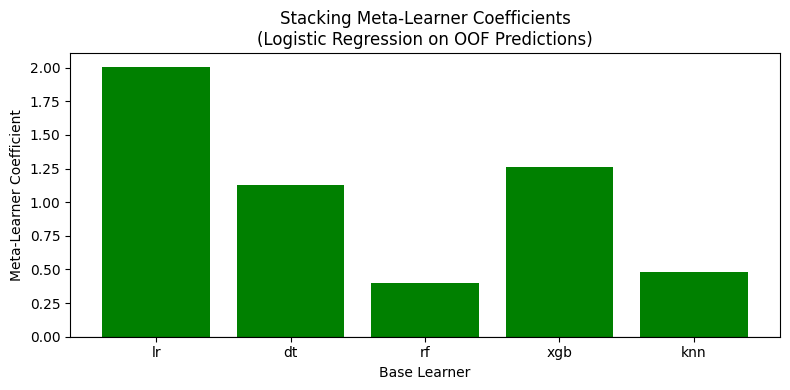


Highest meta-learner weight: lr


In [13]:
# ── 1. Load and Feature Engineer Titanic Data ─────────────────
df_titanic = pd.read_csv('train_titanic.csv')  # Kaggle Titanic train.csv

def engineer_titanic(df):
    """Standard Titanic feature engineering pipeline."""
    d = df.copy()
    
    # Title extraction from Name (captures social status)
    d['Title'] = d['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    d['Title'] = d['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev',
         'Sir','Jonkheer','Dona'], 'Rare')
    d['Title'] = d['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
    d['Title'] = LabelEncoder().fit_transform(d['Title'].fillna('Unknown'))
    
    # Sex encoding
    d['Sex_enc'] = (d['Sex'] == 'male').astype(int)
    
    # Age imputation with median by Title group
    d['Age'] = d.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median()))
    d['Age'].fillna(d['Age'].median(), inplace=True)
    
    # Family size
    d['FamilySize'] = d['SibSp'] + d['Parch'] + 1
    d['IsAlone']    = (d['FamilySize'] == 1).astype(int)
    
    # Fare imputation
    d['Fare'].fillna(d['Fare'].median(), inplace=True)
    d['Fare_log'] = np.log1p(d['Fare'])  # Log-transform skewed fare
    
    # Embarked imputation and encoding
    d['Embarked'].fillna(d['Embarked'].mode()[0], inplace=True)
    d['Embarked_enc'] = LabelEncoder().fit_transform(d['Embarked'])
    
    features = ['Pclass', 'Sex_enc', 'Age', 'FamilySize', 'IsAlone',
                'Fare_log', 'Embarked_enc', 'Title']
    return d[features], d['Survived']

X_tit, y_tit = engineer_titanic(df_titanic)
X_tit = X_tit.values
y_tit = y_tit.values

# ── Train/Test split (80/20 stratified) ───────────────────────
X_tit_tr, X_tit_te, y_tit_tr, y_tit_te = train_test_split(
    X_tit, y_tit, test_size=0.20, stratify=y_tit, random_state=SEED)

# ── 2 & 3. Stacking with StackingClassifier ───────────────────
# Level-0 base learners
scaler_tit = StandardScaler()  # Scale for LR and KNN

base_learners = [
    ('lr',   LogisticRegression(max_iter=1000, random_state=SEED)),
    ('dt',   DecisionTreeClassifier(max_depth=5, random_state=SEED)),
    ('rf',   RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('xgb',  xgb.XGBClassifier(n_estimators=100, use_label_encoder=False,
                                 eval_metric='logloss', random_state=SEED,
                                 verbosity=0)),
    ('knn',  KNeighborsClassifier(n_neighbors=5))
]

# Meta-learner: Logistic Regression
meta_learner = LogisticRegression(max_iter=1000, random_state=SEED)

# StackingClassifier uses 5-fold OOF predictions by default (cv=5)
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,                     # 5-fold OOF for meta-feature construction
    stack_method='predict_proba',  # Use probabilities as meta-features
    passthrough=False,        # Only use OOF proba as meta-features
    n_jobs=-1)

stacking_clf.fit(X_tit_tr, y_tit_tr)

# ── 4. Comparison Table ───────────────────────────────────────
comparison_rows = []

# Evaluate each base learner individually (train on full train set)
for name, clf in base_learners:
    clf.fit(X_tit_tr, y_tit_tr)
    prob_te = clf.predict_proba(X_tit_te)[:, 1]
    pred_te = clf.predict(X_tit_te)
    comparison_rows.append({
        'Model': name.upper(),
        'AUC-ROC': round(roc_auc_score(y_tit_te, prob_te), 4),
        'Accuracy': round(accuracy_score(y_tit_te, pred_te), 4)
    })

# Stacking ensemble
stack_prob = stacking_clf.predict_proba(X_tit_te)[:, 1]
stack_pred = stacking_clf.predict(X_tit_te)
comparison_rows.append({
    'Model': 'STACKING ENSEMBLE',
    'AUC-ROC': round(roc_auc_score(y_tit_te, stack_prob), 4),
    'Accuracy': round(accuracy_score(y_tit_te, stack_pred), 4)
})

comp_df = pd.DataFrame(comparison_rows).set_index('Model')
print("── Base Learners vs. Stacking Ensemble ──")
display(comp_df)

# ── 5. Meta-learner coefficients ──────────────────────────────
meta_coefs = stacking_clf.final_estimator_.coef_[0]
learner_names = [name for name, _ in base_learners]

fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = ['green' if c > 0 else 'red' for c in meta_coefs]
ax.bar(learner_names, meta_coefs, color=colors_coef)
ax.axhline(0, color='black', lw=0.8)
ax.set(xlabel='Base Learner', ylabel='Meta-Learner Coefficient',
       title='Stacking Meta-Learner Coefficients\n(Logistic Regression on OOF Predictions)')
plt.tight_layout()
plt.savefig('bonus_meta_coefs.png', dpi=150)
plt.show()

print("\nHighest meta-learner weight:", learner_names[np.argmax(np.abs(meta_coefs))])

### Interpretation — Bonus
OOF predictions are essential because in-sample predictions from overfit models
(e.g., unpruned trees) are artificially perfect — the meta-learner would assign them
high weight based on spurious in-sample performance, collapsing at test time.
OOF predictions simulate true test-time generalisation for each training observation,
preventing leakage between the base and meta-learning levels.

Finance connection: stacking parallels multi-signal portfolio construction — the
meta-learner learns which base model (alpha signal) has historically been most reliable
on held-out data, analogous to weighting strategies by out-of-sample Sharpe ratio.